In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('naukri_jobs.csv')

# First look at the data
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (30000, 11)

Column Names:
 ['Uniq Id', 'Crawl Timestamp', 'Job Title', 'Job Salary', 'Job Experience Required', 'Key Skills', 'Role Category', 'Location', 'Functional Area', 'Industry', 'Role']

First 5 rows:


,Uniq Id,Crawl Timestamp,Job Title,Job Salary,Job Experience Required,Key Skills,Role Category,Location,Functional Area,Industry,Role
0,9be62c49a0b7ebe982a4af1edaa7bc5f,2019-07-05 01:46:07 +0000,Digital Media Planner,Not Disclosed by Recruiter,5 - 10 yrs,Media Planning| Digital Media,Advertising,Mumbai,"Marketing , Advertising , MR , PR , Media Plan...","Advertising, PR, MR, Event Management",Media Planning Executive/Manager
1,3c52d436e39f596b22519da2612f6a56,2019-07-06 08:04:50 +0000,Online Bidding Executive,Not Disclosed by Recruiter,2 - 5 yrs,pre sales| closing| software knowledge| clien...,Retail Sales,"Pune,Pune","Sales , Retail , Business Development","IT-Software, Software Services",Sales Executive/Officer
2,ffad8a2396c60be2bf6d0e2ff47c58d4,2019-08-05 15:50:44 +0000,Trainee Research/ Research Executive- Hi- Tec...,Not Disclosed by Recruiter,0 - 1 yrs,Computer science| Fabrication| Quality check|...,R&D,Gurgaon,"Engineering Design , R&D","Recruitment, Staffing",R&D Executive
3,7b921f51b5c2fb862b4a5f7a54c37f75,2019-08-05 15:31:56 +0000,Technical Support,"2,00,000 - 4,00,000 PA.",0 - 5 yrs,Technical Support,Admin/Maintenance/Security/Datawarehousing,Mumbai,"IT Software - Application Programming , Mainte...","IT-Software, Software Services",Technical Support Engineer
4,2d8b7d44e138a54d5dc841163138de50,2019-07-05 02:48:29 +0000,Software Test Engineer -hyderabad,Not Disclosed by Recruiter,2 - 5 yrs,manual testing| test engineering| test cases|...,Programming & Design,Hyderabad,IT Software - QA & Testing,"IT-Software, Software Services",Testing Engineer


In [3]:
len(df)

30000

In [5]:
df.isnull().sum()

Uniq Id                       0
Crawl Timestamp               0
Job Title                   575
Job Salary                   50
Job Experience Required     573
Key Skills                 1271
Role Category              2305
Location                    577
Functional Area             573
Industry                    573
Role                        901
dtype: int64

In [6]:
df['Key Skills'].head(10)

0                        Media Planning| Digital Media
1     pre sales| closing| software knowledge| clien...
2     Computer science| Fabrication| Quality check|...
3                                    Technical Support
4     manual testing| test engineering| test cases|...
5     adobe experience manager| digital| digital ma...
6     channel partners| real estate| negotiation| p...
7     TFS| Azure| Git| VSTS| Docker| DynaTrace| Spl...
8                                                  Bde
9     technical support| support services| applicat...
Name: Key Skills, dtype: object

In [7]:
df=df.dropna(subset=['Key Skills'])

In [9]:
len(df)

28729

In [10]:
df['Job Title'] = df['Job Title'].fillna('Not Specified')
df['Location'] = df['Location'].fillna('Not Specified')
df['Industry'] = df['Industry'].fillna('Not Specified')
df['Role'] = df['Role'].fillna('Not Specified')
df['Job Experience Required'] = df['Job Experience Required'].fillna('Not Specified')

In [12]:
df['Key Skills']=df['Key Skills'].str.lower()
df['Key Skills']=df['Key Skills'].str.replace('|',' ',regex=False)
df['Key Skills']=df['Key Skills'].str.strip()

In [13]:
len(df)

28729

In [15]:
df['Key Skills'].head()

0                        media planning  digital media
1    pre sales  closing  software knowledge  client...
2    computer science  fabrication  quality check  ...
3                                    technical support
4    manual testing  test engineering  test cases  ...
Name: Key Skills, dtype: object

In [16]:
df.isnull().sum()

Uniq Id                       0
Crawl Timestamp               0
Job Title                     0
Job Salary                    3
Job Experience Required       0
Key Skills                    0
Role Category              1719
Location                      0
Functional Area             356
Industry                      0
Role                          0
dtype: int64

/var/folders/78/s195ng090w7db1ltfr82pdcw0000gn/T/ipykernel_10203/1696196072.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')


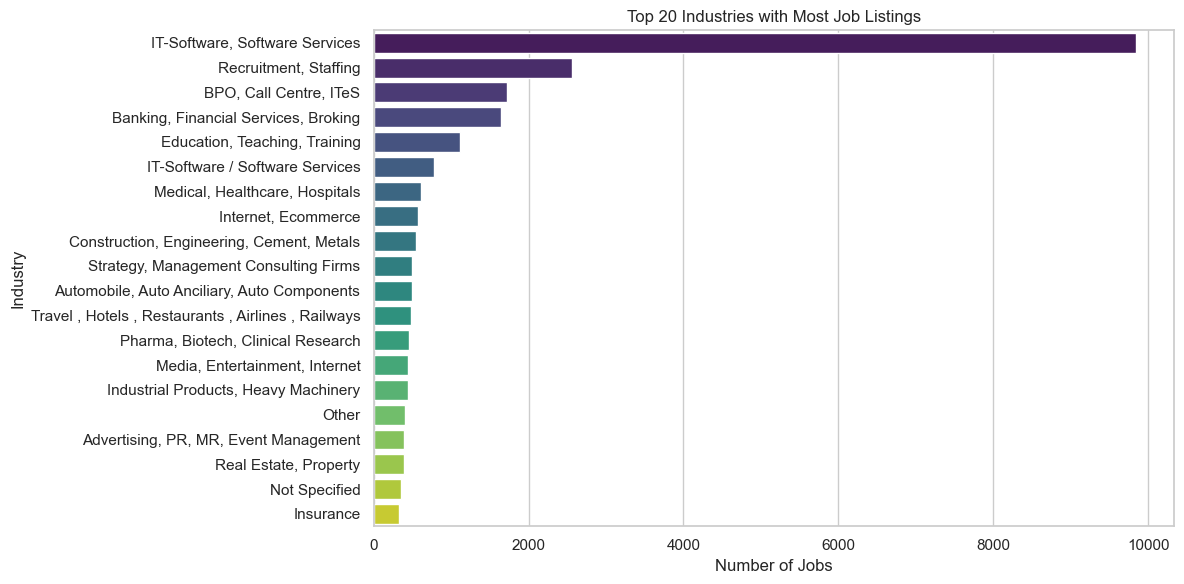

/var/folders/78/s195ng090w7db1ltfr82pdcw0000gn/T/ipykernel_10203/1696196072.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')


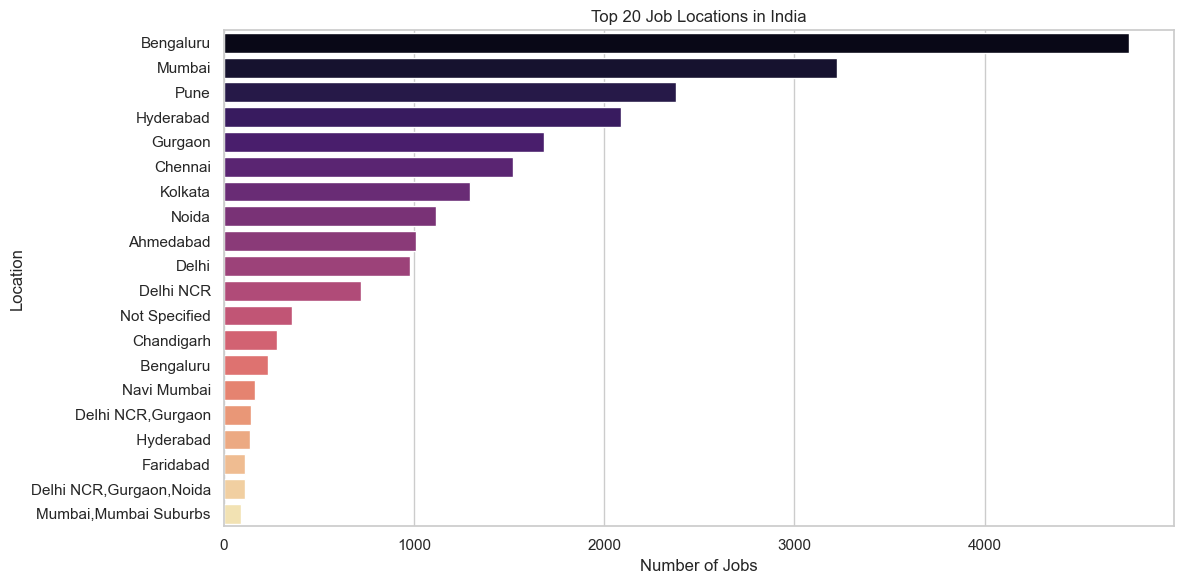

/var/folders/78/s195ng090w7db1ltfr82pdcw0000gn/T/ipykernel_10203/1696196072.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Skill', data=top_skills, palette='coolwarm')


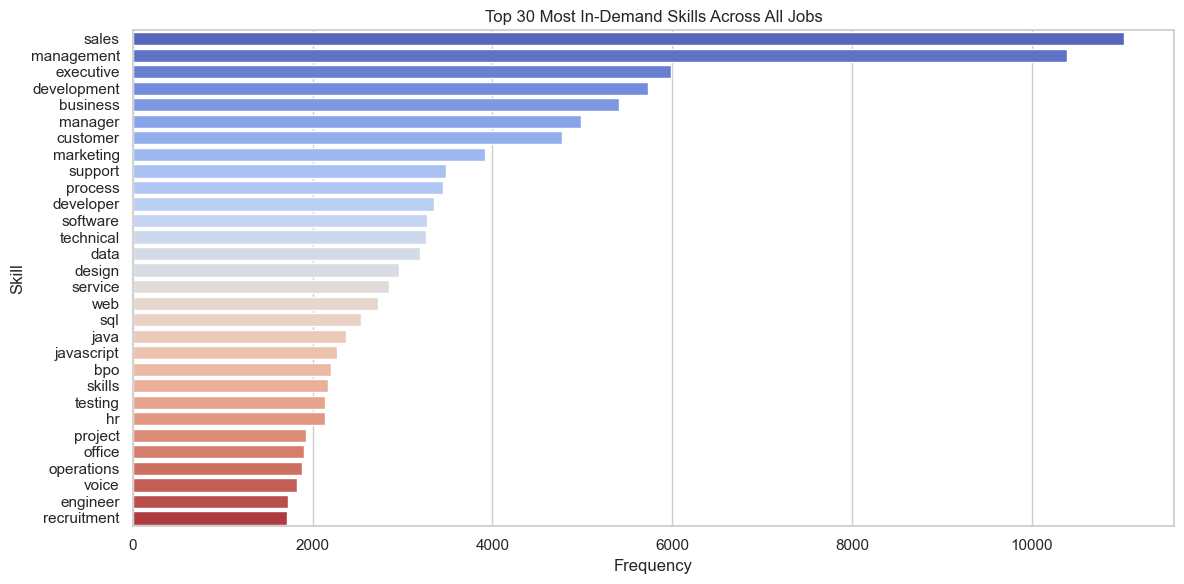

In [17]:
# Setting up the visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---- Graph 1: Top 20 Industries ----
# Why? Shows which industries have the most job listings
plt.figure()
top_industries = df['Industry'].value_counts().head(20)
sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')
plt.title('Top 20 Industries with Most Job Listings')
plt.xlabel('Number of Jobs')
plt.ylabel('Industry')
plt.tight_layout()
plt.savefig('../data/top_industries.png')
plt.show()

# ---- Graph 2: Top 20 Locations ----
# Why? Shows where most jobs are located in India
plt.figure()
top_locations = df['Location'].value_counts().head(20)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='magma')
plt.title('Top 20 Job Locations in India')
plt.xlabel('Number of Jobs')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('../data/top_locations.png')
plt.show()

# ---- Graph 3: Top 30 Most In-Demand Skills ----
# Why? This is the most important graph — shows what skills
# the job market actually wants right now
from collections import Counter

# Split all skills and count them
all_skills = ' '.join(df['Key Skills']).split()
skill_counts = Counter(all_skills)
top_skills = pd.DataFrame(skill_counts.most_common(30), 
                           columns=['Skill', 'Count'])

plt.figure()
sns.barplot(x='Count', y='Skill', data=top_skills, palette='coolwarm')
plt.title('Top 30 Most In-Demand Skills Across All Jobs')
plt.xlabel('Frequency')
plt.ylabel('Skill')
plt.tight_layout()
plt.savefig('../data/top_skills.png')
plt.show()

In [18]:
# Save the cleaned dataset
df.to_csv('../data/cleaned_jobs.csv', index=False)
print("Clean dataset saved! Shape:", df.shape)


Clean dataset saved! Shape: (28729, 11)


In [21]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total Jobs: {len(df)}")
print(f"Total Industries: {df['Industry'].nunique()}")
print(f"Total Locations: {df['Location'].nunique()}")
print(f"Top Industry: {df['Industry'].value_counts().index[0]}")
print(f"Top Location: {df['Location'].value_counts().index[0]}")
print(f"Top Skill: {skill_counts.most_common(1)[0][0]}")
print("=" * 50)

DATASET SUMMARY
Total Jobs: 28729
Total Industries: 123
Total Locations: 2524
Top Industry: IT-Software, Software Services
Top Location: Bengaluru
Top Skill: sales
